In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
import sklearn
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, accuracy_score

warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("winequality_red.csv")


In [3]:
# Feature and Target
X = df.drop('quality' , axis = 1)
y = df['quality']

In [11]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

x_train, x_test, y_train, y_test=train_test_split(
    X_scaled, y, random_state=42, test_size=0.2
)

model = LinearRegression()
model.fit(x_train, y_train)

y_pred = model.predict(x_test)


 Linear Regression Preformace
R2 Score: 0.4031803412790679
MSE: 0.39002514396431703
MAE: 0.5035304415524666
Accuracy: 0.571875


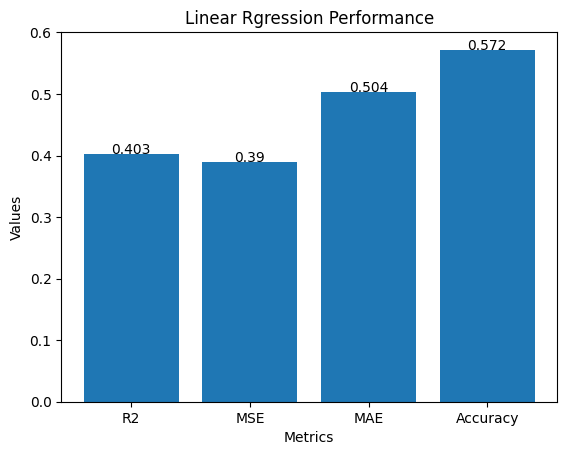

In [15]:
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

y_pred_round = np.round(y_pred)
acc = accuracy_score(y_test, y_pred_round)

print("\n Linear Regression Preformace")
print("R2 Score:", r2)
print("MSE:", mse)
print("MAE:", mae)
print("Accuracy:", acc)

metrics = ['R2', 'MSE', 'MAE', 'Accuracy']
values = [r2, mse, mae, acc]

plt.figure()
plt.bar(metrics, values)

for i, v in enumerate(values):
    plt.text(i, v, str(round(v, 3)), ha='center')

plt.title("Linear Rgression Performance")
plt.xlabel("Metrics")
plt.ylabel("Values")
plt.show()

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, accuracy_score
from sklearn.preprocessing import StandardScaler

from sklearn. linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

def load_data (path) :
    df = pd.read_csv('winequality_red.csv', sep=',') # Changed separator from ';' to ','
    if df.shape [1] == 1:
       df = df [df. columns [0]].str.split(',', expand=True) # Changed separator from ';' to ','
       df = df.apply(pd.to_numeric)
    return df

def preprocess(df):
    df = df[(df['alcohol'] < 14) & (df['volatile acidity'] < 1.2)] # Fixed typo: changed '1,2' to '1.2'
    df['alcohol_acidity_ratio'] = df['alcohol'] / df['volatile acidity']

    return df

In [17]:
def prepare_data(df):

   X = df.drop('quality', axis=1)
   y = df['quality']

   scaler = StandardScaler()
   X_scaled = scaler.fit_transform(X)

   return train_test_split(X_scaled, y, test_size=0.2, random_state=42)

def evaluate_model (name, model, x_test, y_test):
    y_pred = model.predict(x_test)

    r2 = r2_score (y_test, y_pred)
    mse = mean_squared_error (y_test, y_pred)
    mae = mean_absolute_error (y_test, y_pred)

    y_pred_round = np.round(y_pred)
    acc = accuracy_score(y_test, y_pred_round)

    print(f"\n {name} Performance")
    print("R2:", r2)
    print("MSE:", mse)
    print("MAE:", mae)
    print("Accuracy:", acc)
    return r2, mse, mae, acc

In [18]:
def plot_comparison(lr_metrics, rf_metrics):
  labels = ['R2', 'MSE', 'MAE', 'Accuracy']
  x = np.arange(len(labels))

  plt.figure()

  plt.bar(x - 0.2, lr_metrics, width=0.4, label='Linear Regression')
  plt.bar(x + 0.2, rf_metrics, width=0.4, label='Random Forest')

  plt.xticks(x, labels)
  plt.title("Model Comparison")

  for i, v in enumerate(lr_metrics):
    plt.text(i - 0.2, v, round(v, 2), ha='center')

  for i, v in enumerate(rf_metrics):
    plt.text(i + 0.2, v, round(v, 2), ha='center')

  plt.legend()
  plt.show()

 Wine Quality ML Pipeline

 Linear Regression Performance
R2: 0.3859653305037022
MSE: 0.3827363760105479
MAE: 0.4871784604909098
Accuracy: 0.5911949685534591

 Random Forest Performance
R2: 0.48790587851074607
MSE: 0.3191954102459421
MAE: 0.4221199533972675
Accuracy: 0.6918238993710691


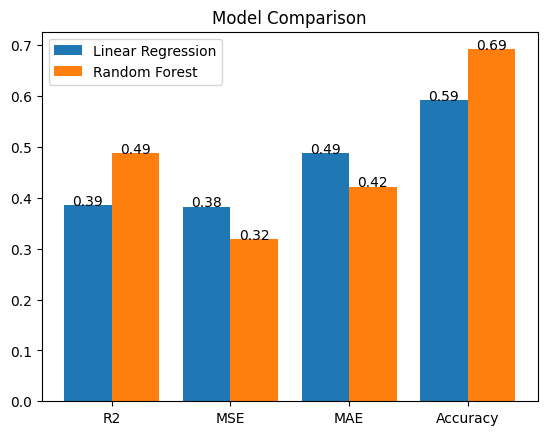

In Pipeline Completed!


In [22]:
def main():
    print(" Wine Quality ML Pipeline")
    df = load_data('winequality_red.csv')
    df = preprocess(df)

    x_train, x_test, y_train, y_test = prepare_data(df)
    lr_model = LinearRegression()
    lr_model.fit(x_train, y_train)

    lr_metrics = evaluate_model("Linear Regression", lr_model, x_test, y_test)

    rf_model = RandomForestRegressor(
       n_estimators=300,
       max_depth=12,
       random_state=42
)
    rf_model.fit(x_train, y_train)

    rf_metrics = evaluate_model("Random Forest", rf_model, x_test, y_test)

    plot_comparison(lr_metrics, rf_metrics)

    print("\n Pipeline Completed!")

if __name__ == "__main__":
  main()